# Knowledge Graph — Notebook 1
## Why Do We Need a Knowledge Graph?

### Concept-to-Code (C2C)

In this notebook we will learn Knowledge Graphs by following:

    Problem
       ↓
    Concept
       ↓
    Representation
       ↓
    Code
       ↓
    Experiment
       ↓
    Observation
       ↓
    Comparison
       ↓
    Conclusion

We will use only Python.

No external libraries are required.

### Learning objectives

By the end of this notebook, you should be able to:

1. Identify entities and relationships.
2. Represent knowledge as triples.
3. Understand nodes and edges.
4. Build a simple graph representation.
5. Retrieve facts from a graph.
6. Perform simple graph traversal.
7. Understand a multi-hop query.
8. Explain why Knowledge Graphs are useful for
   relationship-rich problems.
9. Distinguish the role of a KG from a relational
   database and a vector store.

# 1. Start With a Real-World Problem

Suppose we want to build a Travel Planning application.

We know the following facts:

- Chennai is located in Tamil Nadu.
- Mahabalipuram is near Chennai.
- Mahabalipuram is a heritage destination.
- Marina Beach is located in Chennai.
- Chennai is connected to Bengaluru.
- Bengaluru is connected to Mysuru.
- Hotel SeaView is located in Mahabalipuram.
- Hotel SeaView costs ₹3500 per night.

A human can easily understand these statements.

But our computer needs a representation of this knowledge.

More importantly, suppose a traveller asks:

> Which heritage destinations are near Chennai?

Or:

> Which cities can I reach from Chennai through Bengaluru?

Or:

> Which heritage destination near Chennai has a hotel
> costing less than ₹4000?

These questions are not just about individual facts.

They are about the CONNECTIONS between facts.

That is the problem we are going to investigate.

In [1]:
# Our first piece of knowledge

fact = "Mahabalipuram is near Chennai."

print(fact)

Mahabalipuram is near Chennai.


## Observe

The sentence is easy for a human to understand.

But if we want the computer to reason about this information,
we should identify its components.

The sentence:

    Mahabalipuram is near Chennai.

contains:

    Mahabalipuram
          ↓
       relationship
          ↓
       Chennai

The two things are:

    Mahabalipuram
    Chennai

The relationship is:

    NEAR

So we can represent the fact as:

    Mahabalipuram → NEAR → Chennai

In [2]:
subject = "Mahabalipuram"
relationship = "NEAR"
object_ = "Chennai"

print("Subject     :", subject)
print("Relationship:", relationship)
print("Object      :", object_)

Subject     : Mahabalipuram
Relationship: NEAR
Object      : Chennai


# 2. The Triple

We have now represented one fact using three components:

    Subject → Predicate → Object

For example:

    Mahabalipuram → NEAR → Chennai

This is called a TRIPLE.

In Knowledge Graph terminology:

    Subject   = entity
    Predicate = relationship
    Object    = entity

A triple therefore represents a meaningful fact.

Example:

    Chennai → LOCATED_IN → Tamil Nadu

means:

    Chennai is located in Tamil Nadu.

In [3]:
# Representing a fact as a Python tuple

triple = (
    "Mahabalipuram",
    "NEAR",
    "Chennai"
)

print(triple)

('Mahabalipuram', 'NEAR', 'Chennai')


In [4]:
# Access the individual parts of the triple

print("Subject     :", triple[0])
print("Relationship:", triple[1])
print("Object      :", triple[2])

Subject     : Mahabalipuram
Relationship: NEAR
Object      : Chennai


## C2C: Concept → Code

We can now see the Concept-to-Code transformation.

### Concept

A fact can be represented as:

    Subject → Relationship → Object

### Code

We represent it as:

    (subject, relationship, object)

Therefore:

    Mahabalipuram → NEAR → Chennai

becomes:

    ("Mahabalipuram", "NEAR", "Chennai")

This simple representation is the foundation of
many Knowledge Graph representations.

# 3. Create More Knowledge

Let us add more facts about our travel domain.

We will represent every fact as a triple.

Our knowledge includes:

    Chennai → LOCATED_IN → Tamil Nadu

    Mahabalipuram → NEAR → Chennai

    Mahabalipuram → HAS_CATEGORY → Heritage

    Marina Beach → LOCATED_IN → Chennai

    Chennai → CONNECTED_TO → Bengaluru

    Bengaluru → CONNECTED_TO → Mysuru

    Hotel SeaView → LOCATED_IN → Mahabalipuram

    Hotel SeaView → PRICE_PER_NIGHT → 3500

In [5]:
triples = [
    ("Chennai", "LOCATED_IN", "Tamil Nadu"),
    ("Mahabalipuram", "NEAR", "Chennai"),
    ("Mahabalipuram", "HAS_CATEGORY", "Heritage"),
    ("Marina Beach", "LOCATED_IN", "Chennai"),
    ("Chennai", "CONNECTED_TO", "Bengaluru"),
    ("Bengaluru", "CONNECTED_TO", "Mysuru"),
    ("Hotel SeaView", "LOCATED_IN", "Mahabalipuram"),
    ("Hotel SeaView", "PRICE_PER_NIGHT", 3500)
]

print("Number of facts:", len(triples))

Number of facts: 8


In [6]:
# Display all the triples in a readable form

for subject, relationship, object_ in triples:
    print(
        subject,
        "--",
        relationship,
        "-->",
        object_
    )

Chennai -- LOCATED_IN --> Tamil Nadu
Mahabalipuram -- NEAR --> Chennai
Mahabalipuram -- HAS_CATEGORY --> Heritage
Marina Beach -- LOCATED_IN --> Chennai
Chennai -- CONNECTED_TO --> Bengaluru
Bengaluru -- CONNECTED_TO --> Mysuru
Hotel SeaView -- LOCATED_IN --> Mahabalipuram
Hotel SeaView -- PRICE_PER_NIGHT --> 3500


# 4. From Triples to a Graph

We have a collection of triples.

For example:

    Chennai → LOCATED_IN → Tamil Nadu

The entities become nodes:

    Chennai
    Tamil Nadu

The relationship becomes an edge:

    LOCATED_IN

So conceptually:

    Chennai
       |
       | LOCATED_IN
       ↓
    Tamil Nadu

Similarly:

    Mahabalipuram
          |
          | NEAR
          ↓
       Chennai

A Knowledge Graph is therefore concerned with:

    Nodes
       +
    Relationships
       +
    Meaningful information

We will now construct this graph ourselves using Python.

In [7]:
# Extract all entities/objects from the triples

entities = set()

for subject, relationship, object_ in triples:
    entities.add(subject)
    entities.add(object_)

print("Items appearing as subjects or objects:")
print()

for entity in sorted(entities, key=str):
    print("-", entity)



Items appearing as subjects or objects:

- 3500
- Bengaluru
- Chennai
- Heritage
- Hotel SeaView
- Mahabalipuram
- Marina Beach
- Mysuru
- Tamil Nadu


## Observe

The graph contains entities such as:

    Chennai
    Tamil Nadu
    Mahabalipuram
    Bengaluru
    Mysuru
    Heritage
    Hotel SeaView

Notice that the same entity may participate in
many relationships.

For example, Chennai is connected to:

    Tamil Nadu
    Mahabalipuram
    Bengaluru
    Marina Beach

This is where graph representation becomes interesting.

An entity is not isolated.

It is part of a network of relationships.

In [8]:
# Build an adjacency-style graph.
#
# For every subject, store the relationships
# and the entities connected to it.

graph = {}

for subject, relationship, object_ in triples:

    if subject not in graph:
        graph[subject] = []

    graph[subject].append(
        (relationship, object_)
    )

print(graph)

{'Chennai': [('LOCATED_IN', 'Tamil Nadu'), ('CONNECTED_TO', 'Bengaluru')], 'Mahabalipuram': [('NEAR', 'Chennai'), ('HAS_CATEGORY', 'Heritage')], 'Marina Beach': [('LOCATED_IN', 'Chennai')], 'Bengaluru': [('CONNECTED_TO', 'Mysuru')], 'Hotel SeaView': [('LOCATED_IN', 'Mahabalipuram'), ('PRICE_PER_NIGHT', 3500)]}


In [9]:
# Display the graph in a human-readable form

for entity, connections in graph.items():

    print("\n", entity)

    for relationship, connected_entity in connections:

        print(
            "   --", relationship,
            "-->", connected_entity
        )


 Chennai
   -- LOCATED_IN --> Tamil Nadu
   -- CONNECTED_TO --> Bengaluru

 Mahabalipuram
   -- NEAR --> Chennai
   -- HAS_CATEGORY --> Heritage

 Marina Beach
   -- LOCATED_IN --> Chennai

 Bengaluru
   -- CONNECTED_TO --> Mysuru

 Hotel SeaView
   -- LOCATED_IN --> Mahabalipuram
   -- PRICE_PER_NIGHT --> 3500


# 5. What Have We Actually Built?

We have built a very small Knowledge Graph ourselves.

We did NOT install:

- Neo4j
- NetworkX
- RDFLib
- LangChain
- Pandas

We used only Python data structures.

Conceptually we have:

    Knowledge
        ↓
    Triples
        ↓
    Entities
        ↓
    Relationships
        ↓
    Graph

Of course, this is NOT a production graph database.

A real graph database provides:

- efficient storage
- indexing
- query languages
- transactions
- scalability
- security
- persistence
- optimization

But the underlying CONCEPT is already visible.

In [10]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [11]:
# import matplotlib.pyplot as plt
# import math

# 6. Querying the Knowledge Graph

Now comes an important question:

Can we ask questions about our graph?

Start with a simple question:

> Where is Chennai located?

We need to find:

    Chennai → LOCATED_IN → ?

The question mark represents the unknown object.

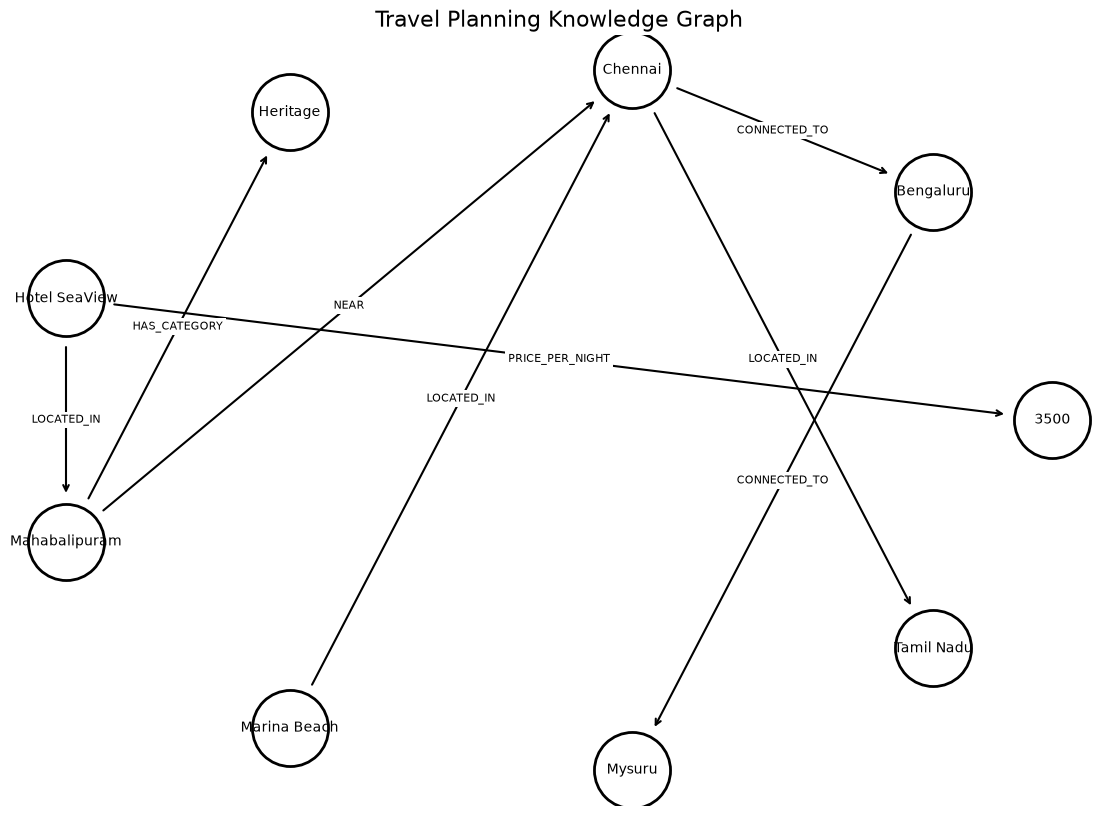

In [12]:
# Visualize the complete Travel Knowledge Graph
# Including literal values such as 3500

import matplotlib.pyplot as plt
import math

# ---------------------------------------------------------
# Extract ALL nodes from the triples
# ---------------------------------------------------------

nodes = set()

for subject, relationship, object_ in triples:
    nodes.add(subject)
    nodes.add(object_)

# Convert everything to string for display
nodes = sorted(nodes, key=str)

# ---------------------------------------------------------
# Assign positions to nodes
# ---------------------------------------------------------

n = len(nodes)

positions = {}

for i, node in enumerate(nodes):

    angle = 2 * math.pi * i / n

    x = math.cos(angle)
    y = math.sin(angle)

    positions[node] = (x, y)

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------

plt.figure(figsize=(14, 10))

# ---------------------------------------------------------
# Draw nodes
# ---------------------------------------------------------

for node, (x, y) in positions.items():

    plt.scatter(
        x,
        y,
        s=3000,
        facecolors="white",
        edgecolors="black",
        linewidths=2,
        zorder=2
    )

    plt.text(
        x,
        y,
        str(node),
        ha="center",
        va="center",
        fontsize=10,
        zorder=3
    )

# ---------------------------------------------------------
# Draw relationships
# ---------------------------------------------------------

for subject, relationship, object_ in triples:

    x1, y1 = positions[subject]
    x2, y2 = positions[object_]

    # Draw directed arrow
    plt.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5,
            shrinkA=35,
            shrinkB=35
        ),
        zorder=1
    )

    # Position relationship label
    label_x = (x1 + x2) / 2
    label_y = (y1 + y2) / 2

    plt.text(
        label_x,
        label_y,
        relationship,
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            pad=2
        ),
        zorder=4
    )

# ---------------------------------------------------------
# Title
# ---------------------------------------------------------

plt.title(
    "Travel Planning Knowledge Graph",
    fontsize=16
)

plt.axis("off")
plt.show()

In [13]:
# Query:
# Where is Chennai located?

for subject, relationship, object_ in triples:

    if (
        subject == "Chennai"
        and relationship == "LOCATED_IN"
    ):
        print("Chennai is located in:", object_)

Chennai is located in: Tamil Nadu


## What did the program do?

It searched for a pattern:

    Chennai → LOCATED_IN → ?

The unknown part was:

    ?

The graph contained:

    Chennai → LOCATED_IN → Tamil Nadu

Therefore the answer is:

    Tamil Nadu

This is basic FACT RETRIEVAL.

We have not performed reasoning yet.

# 7. Query: What Is Near Chennai?

Now consider:

> Which places are near Chennai?

The pattern is:

    ? → NEAR → Chennai

The subject is unknown.

So we search for:

    anything → NEAR → Chennai

In [14]:
# Find all entities that are NEAR Chennai

for subject, relationship, object_ in triples:

    if (
        relationship == "NEAR"
        and object_ == "Chennai"
    ):
        print(subject)

Mahabalipuram


# 8. Query: What Is Connected to Chennai?

Now ask:

> Which city is directly connected to Chennai?

The pattern is:

    Chennai → CONNECTED_TO → ?

In [15]:
for subject, relationship, object_ in triples:

    if (
        subject == "Chennai"
        and relationship == "CONNECTED_TO"
    ):
        print(object_)

Bengaluru


# 9. From Fact Retrieval to Traversal

Now we know:

    Chennai → CONNECTED_TO → Bengaluru

And we also know:

    Bengaluru → CONNECTED_TO → Mysuru

Therefore we can follow the path:

    Chennai
       ↓
    Bengaluru
       ↓
    Mysuru

This requires TWO relationship traversals.

This is called a:

# Multi-Hop Query

A one-hop query:

    A → B

A two-hop query:

    A → B → C

A three-hop query:

    A → B → C → D

The ability to follow relationships is one of the
central ideas behind graph querying.

In [16]:
# Find the city directly connected to Chennai

intermediate_city = None

for subject, relationship, object_ in triples:

    if (
        subject == "Chennai"
        and relationship == "CONNECTED_TO"
    ):
        intermediate_city = object_

print("Intermediate city:", intermediate_city)

Intermediate city: Bengaluru


In [17]:
# Now find what the intermediate city is connected to.

for subject, relationship, object_ in triples:

    if (
        subject == intermediate_city
        and relationship == "CONNECTED_TO"
    ):
        print(
            "Path:",
            "Chennai ->",
            intermediate_city,
            "->",
            object_
        )

Path: Chennai -> Bengaluru -> Mysuru


# 10. The Reasoning Chain

Our answer is:

    Mysuru

But the graph gives us more than the answer.

It gives us the PATH:

    Chennai
       |
       | CONNECTED_TO
       ↓
    Bengaluru
       |
       | CONNECTED_TO
       ↓
    Mysuru

This is useful because we can explain the answer.

Instead of saying only:

    "Mysuru"

we can say:

    "Mysuru is reachable from Chennai through Bengaluru."

This is an example of an EXPLAINABLE PATH.

The relationships used to obtain the answer are visible.

# 11. A More Interesting Query

Now combine different types of knowledge.

Question:

> Which destination near Chennai is a heritage destination?

We need to find an entity satisfying BOTH:

    ? → NEAR → Chennai

and:

    ? → HAS_CATEGORY → Heritage

This means that the same entity must satisfy
two relationships.

In [18]:
# Find heritage destinations near Chennai

near_chennai = set()
heritage_places = set()

for subject, relationship, object_ in triples:

    if (
        relationship == "NEAR"
        and object_ == "Chennai"
    ):
        near_chennai.add(subject)

    if (
        relationship == "HAS_CATEGORY"
        and object_ == "Heritage"
    ):
        heritage_places.add(subject)


answer = near_chennai.intersection(heritage_places)

print("Heritage destinations near Chennai:")

for place in answer:
    print("-", place)

Heritage destinations near Chennai:
- Mahabalipuram


# 12. Why Is This Interesting?

We did not store a fact saying:

    "Mahabalipuram is a heritage destination near Chennai."

Instead, we stored TWO facts:

    Mahabalipuram → NEAR → Chennai

    Mahabalipuram → HAS_CATEGORY → Heritage

The query combined these relationships.

This is an important Knowledge Graph idea:

> New useful knowledge can be obtained by connecting
> existing pieces of knowledge.

# 13. Add Hotels to the Query

We know:

    Mahabalipuram → HAS_CATEGORY → Heritage

and:

    Hotel SeaView → LOCATED_IN → Mahabalipuram

and:

    Hotel SeaView → PRICE_PER_NIGHT → 3500

Now consider:

> Find a heritage destination near Chennai that has
> a hotel costing less than ₹4000.

This question involves several pieces of information.

Conceptually:

    Chennai
       ↑
      NEAR
       |
Mahabalipuram
       |
   HAS_CATEGORY
       ↓
   Heritage

Mahabalipuram
       ↑
  LOCATED_IN
       |
 Hotel SeaView
       |
 PRICE_PER_NIGHT
       ↓
     3500

This is becoming a multi-hop knowledge problem.

In [19]:
# Step 1:
# Find heritage destinations near Chennai.

near_chennai = set()
heritage_places = set()

for subject, relationship, object_ in triples:

    if (
        relationship == "NEAR"
        and object_ == "Chennai"
    ):
        near_chennai.add(subject)

    if (
        relationship == "HAS_CATEGORY"
        and object_ == "Heritage"
    ):
        heritage_places.add(subject)

candidate_places = (
    near_chennai.intersection(heritage_places)
)

print("Candidate destinations:", candidate_places)

Candidate destinations: {'Mahabalipuram'}


In [20]:
# Step 2:
# Find hotels located in those destinations.

candidate_hotels = []

for subject, relationship, object_ in triples:

    if (
        relationship == "LOCATED_IN"
        and object_ in candidate_places
    ):
        candidate_hotels.append(subject)

print("Hotels:", candidate_hotels)

Hotels: ['Hotel SeaView']


In [21]:
# Step 3:
# Find the price of each candidate hotel.

for hotel in candidate_hotels:

    for subject, relationship, object_ in triples:

        if (
            subject == hotel
            and relationship == "PRICE_PER_NIGHT"
        ):

            print(
                hotel,
                "costs ₹",
                object_
            )

Hotel SeaView costs ₹ 3500


In [22]:
# Step 4:
# Apply the budget condition.

budget = 4000

for hotel in candidate_hotels:

    for subject, relationship, object_ in triples:

        if (
            subject == hotel
            and relationship == "PRICE_PER_NIGHT"
            and object_ < budget
        ):

            print(
                "Recommended hotel:",
                hotel,
                "| Price: ₹",
                object_
            )

Recommended hotel: Hotel SeaView | Price: ₹ 3500


# 14. Look at the Reasoning Chain

We obtained:

    Hotel SeaView

But why?

The Knowledge Graph allows us to trace the relationships:

    Hotel SeaView
          ↓
      LOCATED_IN
          ↓
    Mahabalipuram
          ↓
      HAS_CATEGORY
          ↓
       Heritage

and:

    Mahabalipuram
          ↓
         NEAR
          ↓
       Chennai

and:

    Hotel SeaView
          ↓
    PRICE_PER_NIGHT
          ↓
        ₹3500

Therefore:

    Heritage
       +
    Near Chennai
       +
    Hotel price < ₹4000
       ↓
    Hotel SeaView

This is a reasoning chain constructed from
connected facts.

# 15. Now Ask: Can a Relational Database Do This?

YES.

A relational database can store all this information.

For example, we could have:

    CITY
    PLACE
    HOTEL
    CONNECTION

and use SQL JOIN operations.

Therefore, the correct conclusion is NOT:

    "Relational databases cannot do this."

The correct question is:

> Which representation makes relationship-rich questions
> natural to express and explore?

For simple structured records, relational databases
are extremely effective.

For highly interconnected knowledge and multi-hop
relationship exploration, graph representation becomes
particularly attractive.

# 16. What About a Vector Store?

A vector store answers a different type of question.

For example:

> Find documents that are semantically similar to
> "heritage places in South India".

This is a semantic similarity problem.

A vector store is very useful here.

But consider:

> Find a heritage destination near Chennai that has
> a hotel below ₹4000 and can be reached through
> a city connected to Bengaluru.

This is primarily a relationship problem.

The important distinction is:

    Vector Store
        ↓
    Semantic Similarity

    Relational Database
        ↓
    Structured Records + Joins

    Knowledge Graph
        ↓
    Entities + Explicit Relationships + Traversal

In real applications, these technologies can also
be combined.

# 17. Our First Definition of a Knowledge Graph

We can now define the concept based on what we have done.

> A Knowledge Graph represents entities and the meaningful
> relationships between them as a connected structure,
> allowing knowledge to be retrieved and explored through
> those relationships.

At the basic level:

    Knowledge Graph
          =
    Nodes
       +
    Relationships
       +
    Properties
       +
    Meaning

# 18. What Makes It a "Knowledge" Graph?

Compare:

    A -------- B
    B -------- C

This is simply a graph structure.

Now compare:

    Chennai
       |
       | CONNECTED_TO
       ↓
    Bengaluru

The relationship has meaning.

Similarly:

    Mahabalipuram
       |
       | HAS_CATEGORY
       ↓
    Heritage

and:

    Hotel SeaView
       |
       | LOCATED_IN
       ↓
    Mahabalipuram

The labels tell us what the relationships mean.

Therefore:

> The semantics of the entities and relationships
> are important in a Knowledge Graph.

# 19. The Big Picture

We started with ordinary sentences:

    "Mahabalipuram is near Chennai."

We identified:

    Entities
        ↓
    Mahabalipuram
    Chennai

Then identified:

    Relationship
        ↓
    NEAR

Then represented the fact as:

    Mahabalipuram → NEAR → Chennai

Then converted the facts into triples.

Then constructed a graph.

Then queried the graph.

Then performed multi-hop traversal.

Then constructed reasoning chains.

This is the Concept-to-Code journey:

    REAL-WORLD KNOWLEDGE
             ↓
          CONCEPT
             ↓
      REPRESENTATION
             ↓
           CODE
             ↓
           QUERY
             ↓
        TRAVERSAL
             ↓
         REASONING

# 20. Mini Challenge

Now modify the Knowledge Graph.

Add these facts:

    Pondicherry is near Chennai.

    Pondicherry is a Heritage destination.

    Hotel Heritage is located in Pondicherry.

    Hotel Heritage costs ₹3000.

Then answer programmatically:

1. Which heritage destinations are near Chennai?

2. Which hotels are located in those destinations?

3. Which hotels cost less than ₹4000?

4. Construct the reasoning chain for the recommendation.

Do NOT manually give the answers.

Write Python code to obtain them.

In [23]:
# CODE HERE
#
# Add the four new triples.

triples.append(
    ("Pondicherry", "NEAR", "Chennai")
)

triples.append(
    ("Pondicherry", "HAS_CATEGORY", "Heritage")
)

triples.append(
    ("Hotel Heritage", "LOCATED_IN", "Pondicherry")
)

triples.append(
    ("Hotel Heritage", "PRICE_PER_NIGHT", 3000)
)

print("Total number of triples:", len(triples))

Total number of triples: 12


In [24]:
#  CODE HERE
#
# Find heritage destinations near Chennai.

near_chennai = set()
heritage_places = set()

for subject, relationship, object_ in triples:

    if (
        relationship == "NEAR"
        and object_ == "Chennai"
    ):
        near_chennai.add(subject)

    if (
        relationship == "HAS_CATEGORY"
        and object_ == "Heritage"
    ):
        heritage_places.add(subject)


destinations = near_chennai.intersection(
    heritage_places
)

print("Heritage destinations near Chennai:")

for destination in destinations:
    print("-", destination)

Heritage destinations near Chennai:
- Pondicherry
- Mahabalipuram


In [25]:
#  CODE HERE
#
# Find hotels in these destinations
# costing less than ₹4000.

budget = 4000

for destination in destinations:

    for hotel, relationship, place in triples:

        if (
            relationship == "LOCATED_IN"
            and place == destination
        ):

            # Find hotel price
            for s, r, price in triples:

                if (
                    s == hotel
                    and r == "PRICE_PER_NIGHT"
                    and price < budget
                ):

                    print(
                        "Destination:",
                        destination
                    )

                    print(
                        "Hotel:",
                        hotel
                    )

                    print(
                        "Price: ₹",
                        price
                    )

                    print()

Destination: Pondicherry
Hotel: Hotel Heritage
Price: ₹ 3000

Destination: Mahabalipuram
Hotel: Hotel SeaView
Price: ₹ 3500



# 21. Reflection

Answer these questions in your own words.

### Q1
What is an entity?

### Q2
What is a relationship?

### Q3
What is a triple?

### Q4
What is the difference between a node and an edge?

### Q5
What is graph traversal?

### Q6
What is a multi-hop query?

### Q7
Why is a reasoning chain useful?

### Q8
Can a relational database represent this information?

### Q9
If yes, why might a KG still be useful?

### Q10

Complete this statement:

> A Knowledge Graph is particularly useful when
> _____________________________________________.

# 22. Final Takeaway

We have built and queried a very small Knowledge Graph
without installing any Knowledge Graph software.

The important learning is NOT the Python code.

The important learning is the concept behind the code.

We learned:

    Entity
       ↓
    Node

    Relationship
       ↓
    Edge

    Fact
       ↓
    Triple

    Connected entities
       ↓
    Graph

    Following relationships
       ↓
    Traversal

    Following several relationships
       ↓
    Multi-hop query

    Connected facts
       ↓
    Reasoning chain

The next question is:

> If we can build this ourselves with Python,
> why do we need a graph database such as Neo4j?

That is the question we will investigate in the
next notebook.